In [1]:
# ============================================================
# Exploratory Data Analysis on Titanic Dataset
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [2]:
# Download the Titanic Dataset
import urllib.request
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
urllib.request.urlretrieve(url, '../data/raw/titanic.csv')
print('Titanic dataset downloaded successfully')

Titanic dataset downloaded successfully


In [3]:
# Load the Dataset
df = pd.read_csv('../data/raw/titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Shape of the Dataset
sh = df.shape
print(f"The Titanic dataset has {sh[0]} rows and {sh[1]} columns")

The Titanic dataset has 891 rows and 12 columns


In [5]:
# See how many columns the Titanic Dataset has and what's the type of the data?
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
# The dataset has 12 columns with the following ML data type:
# PassengerId: Discreate
# Survived: Binary Categorical
# Pclass: Ordinal Categorical
# Name: Object 
# Sex: Binary Categorical
# Age: Continuous
# SibSp: Nominal Categorical
# Parch: Nominal Categorical
# Ticket: Object
# Fare: Continuous
# Cabin: Ordinal Categorical (Not sure)
# Embarked: Nominal Categorical

In [7]:
# Count missing values
missing_count = df.isnull().sum()
missing_count = missing_count[missing_count > 0]
missing_pct = (missing_count / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'missing_count': missing_count,
    'missing_percent': missing_pct
})
missing_df

,missing_count,missing_percent
Age,177,19.87
Cabin,687,77.10
Embarked,2,0.22


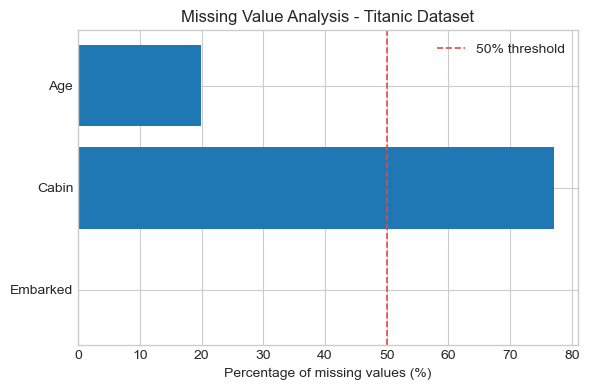

In [8]:
# Visualizing the Missing Data
fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(y= missing_df.index, width=missing_df['missing_percent'])
ax.set_xlabel("Percentage of missing values (%)")
ax.set_title("Missing Value Analysis - Titanic Dataset")
ax.axvline(x=50, color='#E24B4A', linestyle='--', linewidth=1.2, label='50% threshold')
ax.legend(fontsize=10)
ax.invert_yaxis()

plt.savefig('../reports/titanic figures/01_missing_values.png', dpi=150, bbox_inches='tight')
plt.tight_layout()

In [9]:
# Classify missing value reasons
missing_analysis = {
    'Age': ('True missing', 'Fill it with median'),
    'Cabin': ('Does not Exist', 'Fill it with None'),
    'Embarked': ('Data Entry Error', 'Fill it with mode')
}

for col, (cause, action) in missing_analysis.items():
    print(f"{col}: {cause} - {action}")

Age: True missing - Fill it with median
Cabin: Does not Exist - Fill it with None
Embarked: Data Entry Error - Fill it with mode


In [10]:
# Summary Statistics Analysis
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [11]:
# Separate Numerical and Categorical Columns
numerical = df.select_dtypes(include='number').columns.tolist()
categorical = df.select_dtypes(include='object').columns.tolist()
print(len(numerical), len(categorical))

7 5


In [12]:
# Check skewness for Numerical Columns 
skewness = df[numerical].skew()
skewness = skewness[abs(skewness) > 1]
print(f"Flag the column which |skew| > 1: {len(skewness)}")
skewness.round(2)

Flag the column which |skew| > 1: 3


SibSp    3.70
Parch    2.75
Fare     4.79
dtype: float64

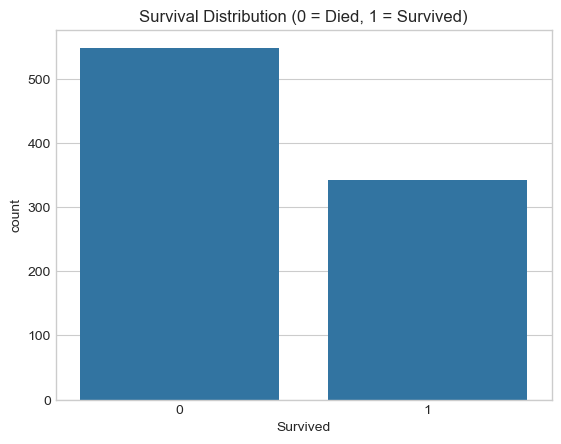

In [13]:
# Visualize the Target Variable
ax = sns.countplot(data=df, x='Survived')
ax.set_title("Survival Distribution (0 = Died, 1 = Survived)")
plt.savefig('../reports/titanic figures/02_target_analysis.png', dpi=150, bbox_inches='tight')

In [14]:
# Calculate the Percentage
survived_pct = df['Survived'].value_counts(normalize=True) * 100
print(survived_pct.round(1))

Survived
0    61.6
1    38.4
Name: proportion, dtype: float64


# EDA Summary Report - Titanic Dataset
**Dataset:** Titanic Dataset

---
## Dataset Overview
**Shape:** 891 rows and 12 columns
**Target Column:** `Survived` (Categorical, Classification Problem)
**Feature Split:** 7 Numerical, 5 Categorical

---
## Key Finding 1 - Missing Values
The Titanic Dataset has 3 missing columns classified as:
| Type | Column | Action |
|---|---|---|
| True missing | Age | Fill it with median |
| Does not Exist | Cabin | Fill it with None |    
| Data Entry Error | Embarked | Fill it with mode |